# 08_02 School days: do school holidays carry forecast signal?

Unlike a bridge day, a school holiday **cannot be derived** from anything the model already
sees. The dates are set per Bundesland by decree, they move by up to three weeks between
Niedersachsen and Nordrhein-Westfalen, and no combination of weekday, month or
holiday-distance reproduces them. If school calendars move grocery demand, this is genuinely
new information.

The feature is `is_school_holiday`, evaluated against the store's own Bundesland, from the
official calendar committed to `reports/config/school_holidays.json` (OpenHolidays API, the
Laender's published periods).

## The mechanism, stated before measuring

During school holidays households travel, so a rural grocery network loses part of its
customer base; those who stay shop differently — longer trips, more grilling, fewer
weekday-lunch purchases. The effect should be strongest in the long Sommerferien and
weakest in the one-day *bewegliche Ferientage*.

## Pre-registered predictions

1. **Level.** Demand differs between school-holiday days and term-time days.
2. **Identification.** The difference survives the strongest available control: comparing
   NI against NW **on the same calendar date**. This is the test that matters, because the
   naive comparison is hopelessly confounded with season — Sommerferien *is* summer.
3. **Error.** Correcting the persisted forecasts on school-holiday days beats the
   **0.053 pp** seed-noise floor from `07_02`, and the refit reproduces it.

The evaluation window is unusually well suited to prediction 2: it runs 2 March to 18 July
2026, in which NI is on Osterferien from 23 March and on Sommerferien from 2 July, while NW
is on Osterferien only from 30 March and starts its Sommerferien after the window ends. On
29 of the 139 evaluation dates the two states disagree, under identical weather and season.

In [1]:
import os
from pathlib import Path
import sys

os.environ.setdefault("OMP_NUM_THREADS", "1")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Project data directory not found.")
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.preparation.calendar_days import bridge_day_dates, school_holiday_dates
from src.data.preparation.distribute_sales_over_active_days import (
    HOLIDAY_SUBDIVISIONS,
    create_germany_holidays,
    store_subdivisions,
)

DATA_GLOB = str(PROJECT_ROOT / "data/processed/transactions_fixed/*.parquet")
BASELINE_FORECASTS = (
    PROJECT_ROOT
    / "reports/results/run_fixed_data/forecasts"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BATCH_FORECASTS = (
    PROJECT_ROOT
    / "reports/results/run_08_bridge_school/forecasts"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BASELINE_IMPORTANCE = (
    PROJECT_ROOT
    / "reports/results/run_fixed_data/feature_importance"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
BATCH_IMPORTANCE = (
    PROJECT_ROOT
    / "reports/results/run_08_bridge_school/feature_importance"
    / "artikel_markt_multi7days_lightgbm_two_stage.csv"
)
FIRST_ORIGIN = pd.Timestamp("2026-03-02")
# Row-grain WAPE standard deviation across five identical fits (07_02).
SEED_NOISE_SD = 0.0531
BIAS_NOISE_SD = 0.1905

SERIES_NI = "#2a78d6"
SERIES_NW = "#eb6834"
INK = "#0b0b0b"
MUTED = "#52514e"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight",
                     "axes.edgecolor": MUTED, "text.color": INK})
con = duckdb.connect()
con.execute("PRAGMA threads=4")

## The school-holiday calendar

In [2]:
YEARS = range(2023, 2027)
bridge = {s: bridge_day_dates(s, YEARS) for s in HOLIDAY_SUBDIVISIONS}
school = {s: school_holiday_dates(s, YEARS) for s in HOLIDAY_SUBDIVISIONS}
holidays = {
    s: {pd.Timestamp(d) for d in create_germany_holidays(s, YEARS)}
    for s in HOLIDAY_SUBDIVISIONS
}
stores = store_subdivisions()
# maerkte.csv lists stores that never appear in the transaction table, so the
# store counts below are taken from the data rather than from the master file.
trading_stores = con.execute(
    f"SELECT DISTINCT MARKT_ID FROM read_parquet('{DATA_GLOB}')"
).df().merge(stores, on="MARKT_ID", how="left")
trading_stores["subdivision"] = trading_stores["subdivision"].fillna("NI")

DATA_START, DATA_END = pd.Timestamp("2023-07-22"), pd.Timestamp("2026-07-21")
rows = []
for state in HOLIDAY_SUBDIVISIONS:
    in_window = sorted(d for d in bridge[state] if DATA_START <= d <= DATA_END)
    rows.append({
        "Bundesland": state,
        "stores in the data": int((trading_stores.subdivision == state).sum()),
        "bridge days in data": len(in_window),
        "school-holiday days in data": len(
            [d for d in school[state] if DATA_START <= d <= DATA_END]
        ),
    })
display(pd.DataFrame(rows))

print("Bridge days inside the transaction window:")
for state in HOLIDAY_SUBDIVISIONS:
    days = sorted(d for d in bridge[state] if DATA_START <= d <= DATA_END)
    print(f"  {state}: " + ", ".join(f"{d.date()} ({d.day_name()[:3]})" for d in days))

,Bundesland,stores in the data,bridge days in data,school-holiday days in data
0,NI,133,10,267
1,NW,59,11,232


Bridge days inside the transaction window:
  NI: 2023-10-02 (Mon), 2023-10-30 (Mon), 2024-05-10 (Fri), 2024-10-04 (Fri), 2024-11-01 (Fri), 2024-12-27 (Fri), 2025-05-02 (Fri), 2025-05-30 (Fri), 2026-01-02 (Fri), 2026-05-15 (Fri)
  NW: 2023-10-02 (Mon), 2024-05-10 (Fri), 2024-05-31 (Fri), 2024-10-04 (Fri), 2024-12-27 (Fri), 2025-05-02 (Fri), 2025-05-30 (Fri), 2025-06-20 (Fri), 2026-01-02 (Fri), 2026-05-15 (Fri), 2026-06-05 (Fri)


In [3]:
window = pd.date_range("2026-03-02", "2026-07-18", freq="D")
disagreement = pd.DataFrame({
    "date": window,
    "NI": [d in school["NI"] for d in window],
    "NW": [d in school["NW"] for d in window],
})
disagreement["states disagree"] = disagreement.NI != disagreement.NW
print(f"evaluation dates: {len(disagreement)}")
print(f"  NI on school holiday: {int(disagreement.NI.sum())}")
print(f"  NW on school holiday: {int(disagreement.NW.sum())}")
print(f"  states disagree:      {int(disagreement['states disagree'].sum())}")
periods = disagreement[disagreement["states disagree"]].date
print(f"  disagreement runs {periods.min().date()} .. {periods.max().date()}")

evaluation dates: 139
  NI on school holiday: 35
  NW on school holiday: 14
  states disagree:      29
  disagreement runs 2026-03-23 .. 2026-07-18


## Prediction 1 — the level, and why the naive answer is wrong

In [4]:
panel = con.execute(f"""
    SELECT MARKT_ID,
           CAST(DATE AS DATE) AS period,
           SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg,
           COUNT(*) AS series
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active
    GROUP BY 1, 2
""").df()
panel["period"] = pd.to_datetime(panel["period"])
panel = panel.merge(stores, on="MARKT_ID", how="left")
panel["subdivision"] = panel["subdivision"].fillna("NI")
panel = panel[panel.demand_kg > 0].copy()

keys = list(zip(panel.subdivision, panel.period))
bridge_pairs = {(s, d) for s in HOLIDAY_SUBDIVISIONS for d in bridge[s]}
school_pairs = {(s, d) for s in HOLIDAY_SUBDIVISIONS for d in school[s]}
panel["is_bridge_day"] = [k in bridge_pairs for k in keys]
panel["is_school_holiday"] = [k in school_pairs for k in keys]

# Signed distance to the nearest public holiday of the store's own Bundesland --
# the quantity the model already carries as `days_to_nearest_event`.
distance = {}
for state in HOLIDAY_SUBDIVISIONS:
    calendar = pd.DatetimeIndex(sorted(holidays[state])).values.astype("datetime64[D]")
    for day in pd.date_range(panel.period.min(), panel.period.max(), freq="D"):
        deltas = (calendar - np.datetime64(day.date())).astype(int)
        distance[(state, day)] = int(deltas[np.argmin(np.abs(deltas))])
panel["days_to_holiday"] = [distance[k] for k in keys]

panel["weekday"] = panel.period.dt.weekday
panel["log_demand"] = np.log(panel.demand_kg)
panel["log_series"] = np.log(panel.series)
panel["store_index"] = panel.demand_kg / panel.groupby("MARKT_ID").demand_kg.transform("mean")
print(f"{len(panel):,} active store-days, {panel.MARKT_ID.nunique()} stores, "
      f"{panel.period.min().date()} to {panel.period.max().date()}")

166,527 active store-days, 192 stores, 2023-07-22 to 2026-07-21


In [5]:
def fixed_effect_regression(frame, treatment, controls, fixed_effects, cluster="period"):
    """Least squares with absorbed fixed effects and cluster-robust errors.

    Returns the treatment coefficient in log points together with its standard
    error, clustered on the supplied column (dates, since a calendar treatment is
    common to every store on a date).
    """
    columns = ["log_demand", treatment] + list(controls)
    values = frame[columns].astype(float).copy()
    for _ in range(50):
        largest = 0.0
        for group in fixed_effects:
            means = values.groupby(frame[group].values).transform("mean")
            largest = max(largest, float(means.abs().to_numpy().max()))
            values = values - means
        if largest < 1e-10:
            break
    y = values["log_demand"].to_numpy()
    x = values[[treatment] + list(controls)].to_numpy()
    inverse = np.linalg.pinv(x.T @ x)
    beta = inverse @ (x.T @ y)
    residual = y - x @ beta
    meat = np.zeros((x.shape[1], x.shape[1]))
    for _, index in frame.groupby(cluster).indices.items():
        score = x[index].T @ residual[index]
        meat += np.outer(score, score)
    groups = frame[cluster].nunique()
    covariance = inverse @ meat @ inverse * groups / max(groups - 1, 1)
    return float(beta[0]), float(np.sqrt(max(covariance[0, 0], 0.0)))


def report_effect(label, coefficient, error):
    display(Markdown(
        f"**{label}** &nbsp; {coefficient * 100:+.2f}% "
        f"(se {error * 100:.2f}, t {coefficient / error:+.1f})"
    ))

In [6]:
panel_keys = panel.assign(
    yearmonth_key=panel.period.dt.to_period("M").astype(str),
    date_key=panel.period.dt.strftime("%Y-%m-%d"),
    is_school_holiday=panel.is_school_holiday.astype(float),
)
naive, naive_error = fixed_effect_regression(
    panel_keys, "is_school_holiday", ["log_series"],
    ["MARKT_ID", "yearmonth_key", "weekday"],
)
report_effect("Store + year-month + weekday fixed effects (confounded with season)",
              naive, naive_error)

within_day, within_error = fixed_effect_regression(
    panel_keys, "is_school_holiday", ["log_series"], ["MARKT_ID", "date_key"],
)
report_effect("Store + **calendar-date** fixed effects (NI against NW on the same day)",
              within_day, within_error)

contrast_dates = panel_keys.groupby("date_key").is_school_holiday.nunique().eq(2).sum()
display(Markdown(
    f"The within-day estimate is identified off **{int(contrast_dates)} dates** on which the "
    "two Bundeslaender disagree."
))

**Store + year-month + weekday fixed effects (confounded with season)** &nbsp; +3.95% (se 2.10, t +1.9)

**Store + **calendar-date** fixed effects (NI against NW on the same day)** &nbsp; -1.16% (se 0.84, t -1.4)

The within-day estimate is identified off **157 dates** on which the two Bundeslaender disagree.

## Prediction 2 — one estimate per holiday type

Aggregating every kind of school holiday into one indicator can hide opposite effects. Each
type is re-estimated against term time with calendar-date fixed effects.

In [7]:
import json

reference = json.loads(
    (PROJECT_ROOT / "reports/config/school_holidays.json").read_text(encoding="utf-8")
)
holiday_type = {}
for entry in reference["periods"]:
    for day in pd.date_range(entry["start"], entry["end"], freq="D"):
        holiday_type[(entry["subdivision"], day)] = entry["name"].lower()
panel_keys["holiday_type"] = [
    holiday_type.get(k, "term time") for k in zip(panel_keys.subdivision, panel_keys.period)
]

rows = []
for kind in ["sommerferien", "osterferien", "herbstferien", "weihnachtsferien",
             "pfingstferien"]:
    subset = panel_keys[
        panel_keys.holiday_type.str.startswith(kind) | (~panel_keys.is_school_holiday.astype(bool))
    ].copy()
    subset["treated"] = subset.holiday_type.str.startswith(kind).astype(float)
    if subset.treated.sum() < 100:
        continue
    contrast_days = int(subset.groupby("date_key").treated.nunique().eq(2).sum())
    coefficient, error = fixed_effect_regression(
        subset, "treated", ["log_series"], ["MARKT_ID", "date_key"]
    )
    # Without a single date on which the two Bundeslaender disagree, the
    # indicator is collinear with the date fixed effects and nothing is
    # identified; report that rather than a spurious coefficient.
    identified = contrast_days > 0 and np.isfinite(error) and error > 1e-12
    rows.append({
        "holiday type": kind,
        "effect %": coefficient * 100 if identified else np.nan,
        "se %": error * 100 if identified else np.nan,
        "t": coefficient / error if identified else np.nan,
        "dates": int(subset[subset.treated == 1].date_key.nunique()),
        "dates with a within-day contrast": contrast_days,
    })
display(pd.DataFrame(rows).set_index("holiday type").round(2))
display(Markdown(
    "A row without a within-day contrast is **not identified** by this design: the two "
    "Bundeslaender are always on that holiday together, so the indicator cannot be "
    "separated from the calendar-date fixed effect."
))

,effect %,se %,t,dates,dates with a within-day contrast
holiday type,,,,,
sommerferien,-0.53,1.31,-0.40,136,71
osterferien,-0.87,1.22,-0.71,48,33
herbstferien,-3.05,2.00,-1.53,56,37
weihnachtsferien,3.41,4.92,0.69,32,5
pfingstferien,NaN,NaN,NaN,3,0


A row without a within-day contrast is **not identified** by this design: the two Bundeslaender are always on that holiday together, so the indicator cannot be separated from the calendar-date fixed effect.

## The natural experiment, read off the forecast errors directly

The regressions above describe *demand*. What decides the batch is whether the **model's
error** moves with the school calendar. Below, the evaluation window is cut into periods
where the two states' calendars agree and where they diverge; if school holidays were
mispriced, the NI−NW gap in forecast/actual should open exactly when the calendars diverge.

In [8]:
FORECAST_COLUMNS = ["ARTIKEL_ID", "MARKT_ID", "origin", "period", "actual",
                    "forecast", "is_active"]


def load_forecasts(path):
    frames = []
    for chunk in pd.read_csv(path, usecols=FORECAST_COLUMNS, chunksize=2_000_000):
        frames.append(chunk[chunk.is_active == True].drop(columns="is_active"))
    frame = pd.concat(frames, ignore_index=True)
    frame["period"] = pd.to_datetime(frame["period"])
    frame["origin"] = pd.to_datetime(frame["origin"])
    frame = frame.merge(stores, on="MARKT_ID", how="left")
    frame["subdivision"] = frame["subdivision"].fillna("NI")
    pairs = list(zip(frame.subdivision, frame.period))
    frame["is_bridge_day"] = [k in bridge_pairs for k in pairs]
    frame["is_school_holiday"] = [k in school_pairs for k in pairs]
    return frame


def wape(forecast, actual):
    return (forecast - actual).abs().sum() / actual.sum() * 100


def grain_metrics(frame, column="forecast"):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum"))
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        actual=("actual", "sum"), forecast=(column, "sum"))
    return {
        "row WAPE": wape(frame[column], frame.actual),
        "article-store-week WAPE": wape(weekly.forecast, weekly.actual),
        "article-day WAPE": wape(article_day.forecast, article_day.actual),
        "relative bias %": (frame[column].sum() - frame.actual.sum())
                           / frame.actual.sum() * 100,
    }

In [9]:
evaluation = load_forecasts(BASELINE_FORECASTS)
baseline_metrics = grain_metrics(evaluation)
display(Markdown(
    f"Baseline two-stage on the state-aware data: "
    f"row WAPE **{baseline_metrics['row WAPE']:.3f}**, "
    f"bias **{baseline_metrics['relative bias %']:+.3f}%**, "
    f"{len(evaluation):,} active rows over {evaluation.origin.nunique()} origins."
))

windows = {
    "Osterferien, NI only (Mar 23-27)": ("2026-03-23", "2026-03-27"),
    "Osterferien, both states (Mar 30-Apr 04)": ("2026-03-30", "2026-04-04"),
    "Osterferien, NW only (Apr 08-11)": ("2026-04-08", "2026-04-11"),
    "term time, both states (May 04-22)": ("2026-05-04", "2026-05-22"),
    "term time, both states (Jun 08-30)": ("2026-06-08", "2026-06-30"),
    "Sommerferien, NI only (Jul 02-18)": ("2026-07-02", "2026-07-18"),
}
rows = []
for label, (start, end) in windows.items():
    frame = evaluation[(evaluation.period >= start) & (evaluation.period <= end)]
    entry = {"window": label}
    for state in HOLIDAY_SUBDIVISIONS:
        part = frame[frame.subdivision == state]
        entry[f"{state} on holiday"] = round(part.is_school_holiday.mean(), 2)
        entry[f"{state} forecast/actual"] = part.forecast.sum() / part.actual.sum()
    entry["NI - NW"] = entry["NI forecast/actual"] - entry["NW forecast/actual"]
    rows.append(entry)
experiment = pd.DataFrame(rows).set_index("window")
display(experiment.round(4))

Baseline two-stage on the state-aware data: row WAPE **57.442**, bias **-1.209%**, 2,498,967 active rows over 20 origins.

,NI on holiday,NI forecast/actual,NW on holiday,NW forecast/actual,NI - NW
window,,,,,
"Osterferien, NI only (Mar 23-27)",1.00,1.0884,0.0,1.1441,-0.0557
"Osterferien, both states (Mar 30-Apr 04)",1.00,0.8560,1.0,0.9149,-0.0588
"Osterferien, NW only (Apr 08-11)",0.00,1.1008,1.0,1.0738,0.0270
"term time, both states (May 04-22)",0.06,0.9231,0.0,0.9469,-0.0238
"term time, both states (Jun 08-30)",0.00,1.0159,0.0,1.0902,-0.0742
"Sommerferien, NI only (Jul 02-18)",1.00,0.9521,0.0,0.9592,-0.0071


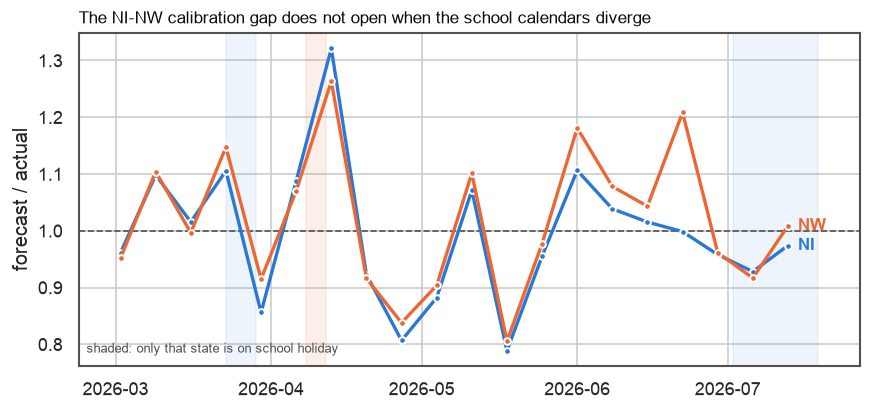

In [10]:
weekly = evaluation.assign(week=evaluation.period.dt.to_period("W").dt.start_time)
calibration = (
    weekly.groupby(["week", "subdivision"])
    .apply(lambda f: f.forecast.sum() / f.actual.sum(), include_groups=False)
    .rename("forecast/actual").reset_index()
)

fig, ax = plt.subplots(figsize=(8.4, 3.6))
for state, colour in [("NI", SERIES_NI), ("NW", SERIES_NW)]:
    part = calibration[calibration.subdivision == state]
    ax.plot(part.week, part["forecast/actual"], linewidth=2, color=colour, zorder=3,
            marker="o", markersize=4, markeredgecolor="white", markeredgewidth=1.2)
    ax.annotate(state, xy=(part.week.iloc[-1], part["forecast/actual"].iloc[-1]),
                xytext=(6, 0), textcoords="offset points", color=colour,
                fontsize=10, va="center", fontweight="bold")
ax.axhline(1.0, color=MUTED, linewidth=1, linestyle="--", zorder=2)

ni_only = [("2026-03-23", "2026-03-29"), ("2026-07-02", "2026-07-19")]
for start, end in ni_only:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=SERIES_NI, alpha=0.08, zorder=1)
ax.axvspan(pd.Timestamp("2026-04-08"), pd.Timestamp("2026-04-12"),
           color=SERIES_NW, alpha=0.10, zorder=1)
ax.annotate("shaded: only that state is on school holiday", xy=(0.01, 0.04),
            xycoords="axes fraction", fontsize=8, color=MUTED)
ax.set_ylabel("forecast / actual")
ax.set_xlabel("")
ax.set_title("The NI-NW calibration gap does not open when the school calendars diverge",
             fontsize=10, color=INK, loc="left")
ax.margins(x=0.06)
plt.show()

## Prediction 3 — per-article effects and the out-of-sample screen

A pooled zero can hide article responses of opposite sign — that is exactly what made the
temperature feature work in `06_02`. So the effect is estimated **per article**, its
dispersion tested against estimation noise, and the shrunk estimates applied out of sample.

In [11]:
history = con.execute(f"""
    SELECT ARTIKEL_ID, MARKT_ID, CAST(DATE AS DATE) AS period,
           SUM(ABVERKAUFTE_MENGE_KG) AS demand_kg
    FROM read_parquet('{DATA_GLOB}')
    WHERE is_active AND CAST(DATE AS DATE) < DATE '{FIRST_ORIGIN.date()}'
    GROUP BY 1, 2, 3
""").df()
history["period"] = pd.to_datetime(history["period"])
history = history.merge(stores, on="MARKT_ID", how="left")
history["subdivision"] = history["subdivision"].fillna("NI")
pairs = list(zip(history.subdivision, history.period))
history["is_bridge_day"] = np.fromiter((k in bridge_pairs for k in pairs), int, len(history))
history["is_school_holiday"] = np.fromiter((k in school_pairs for k in pairs), int, len(history))
history["weekday"] = history.period.dt.weekday
history["yearmonth"] = history.period.dt.to_period("M").astype(str)

# The store dimension carries no calendar variation within a Bundesland, so
# stores are pooled per article, state and date before estimating.
article_days = (
    history.groupby(["ARTIKEL_ID", "subdivision", "period", "weekday", "yearmonth",
                     "is_bridge_day", "is_school_holiday"], as_index=False)
    .agg(demand_kg=("demand_kg", "sum"), stores=("MARKT_ID", "nunique"))
)
article_days = article_days[article_days.demand_kg > 0].copy()
article_days["log_demand"] = np.log(article_days.demand_kg)
article_days["log_series"] = np.log(article_days.stores)


def per_article_effects(treatment, fixed_effects, minimum_treated):
    """Fit one pre-origin effect per article and shrink it toward the pooled one."""
    estimates = []
    for article, frame in article_days.groupby("ARTIKEL_ID"):
        if frame[treatment].sum() < minimum_treated or len(frame) < 60:
            continue
        if frame[treatment].nunique() < 2 or frame.period.nunique() < 5:
            continue
        try:
            coefficient, error = fixed_effect_regression(
                frame, treatment, ["log_series"], fixed_effects
            )
        except np.linalg.LinAlgError:
            continue
        if not np.isfinite(error) or error <= 0:
            continue
        estimates.append({"ARTIKEL_ID": article, "beta": coefficient, "se": error})
    estimates = pd.DataFrame(estimates)
    weights = 1 / estimates.se ** 2
    pooled = float((weights * estimates.beta).sum() / weights.sum())
    q_statistic = float((weights * (estimates.beta - pooled) ** 2).sum())
    degrees = len(estimates) - 1
    tau_squared = max(
        0.0,
        (q_statistic - degrees)
        / (weights.sum() - (weights ** 2).sum() / weights.sum()),
    )
    estimates["shrunk"] = pooled + (
        tau_squared / (tau_squared + estimates.se ** 2)
    ) * (estimates.beta - pooled)
    summary = {
        "articles": len(estimates),
        "pooled %": pooled * 100,
        "tau %": np.sqrt(tau_squared) * 100,
        "I^2 %": max(0.0, (q_statistic - degrees) / q_statistic) * 100,
        "share |t| > 2": float((estimates.beta.abs() / estimates.se > 2).mean()),
        "p10 %": estimates.beta.quantile(0.10) * 100,
        "p90 %": estimates.beta.quantile(0.90) * 100,
    }
    return estimates, summary


def correction_screen(evaluation, estimates, flag, baseline):
    """Apply pre-origin article effects to the persisted forecasts."""
    results = []
    for kind in ["shrunk", "beta"]:
        effect = evaluation.ARTIKEL_ID.map(
            estimates.set_index("ARTIKEL_ID")[kind]
        ).fillna(0.0).to_numpy()
        evaluation["corrected"] = np.clip(
            evaluation.forecast * (1 + effect * evaluation[flag].to_numpy()), 0, None
        )
        metrics = grain_metrics(evaluation, "corrected")
        results.append({
            "effects": "empirical-Bayes shrunk" if kind == "shrunk" else "raw per article",
            **{name: value - baseline[name] for name, value in metrics.items()},
        })
    table = pd.DataFrame(results).set_index("effects")
    table["row WAPE in seed sd"] = table["row WAPE"] / SEED_NOISE_SD
    return table

In [12]:
school_effects, school_summary = per_article_effects(
    "is_school_holiday", ["period"], minimum_treated=30
)
display(pd.Series(school_summary).round(3).to_frame("per-article school-holiday effect"))
display(Markdown(
    "`I^2` is the share of the spread across articles that is real heterogeneity rather "
    "than estimation noise; `tau` is the implied standard deviation of the true effects."
))
display(correction_screen(
    evaluation, school_effects, "is_school_holiday", baseline_metrics
).round(4))

,per-article school-holiday effect
articles,205.000
pooled %,0.444
tau %,7.135
I^2 %,59.852
share |t| > 2,0.161
p10 %,-20.535
p90 %,21.167


`I^2` is the share of the spread across articles that is real heterogeneity rather than estimation noise; `tau` is the implied standard deviation of the true effects.

,row WAPE,article-store-week WAPE,article-day WAPE,relative bias %,row WAPE in seed sd
effects,,,,,
empirical-Bayes shrunk,0.0271,0.0136,0.0104,0.1468,0.5101
raw per article,0.1181,0.1311,0.1684,0.2513,2.2239


In [13]:
global_ratio = evaluation.forecast.sum() / evaluation.actual.sum()
evaluation["weekday"] = evaluation.period.dt.weekday
oracle_rows = []
for cells in (["is_school_holiday"], ["is_school_holiday", "subdivision"],
              ["is_school_holiday", "subdivision", "weekday"]):
    evaluation["oracle"] = evaluation.forecast
    for _, frame in evaluation.groupby(cells, observed=True):
        ratio = frame.forecast.sum() / frame.actual.sum()
        evaluation.loc[frame.index, "oracle"] = frame.forecast * (global_ratio / ratio)
    metrics = grain_metrics(evaluation, "oracle")
    oracle_rows.append({
        "recalibration cells": " x ".join(cells),
        **{name: metrics[name] - baseline_metrics[name] for name in metrics},
    })
oracle = pd.DataFrame(oracle_rows).set_index("recalibration cells")
oracle["row WAPE in seed sd"] = oracle["row WAPE"] / SEED_NOISE_SD
display(oracle.round(4))

,row WAPE,article-store-week WAPE,article-day WAPE,relative bias %,row WAPE in seed sd
recalibration cells,,,,,
is_school_holiday,-0.0330,-0.0316,-0.0774,0.0,-0.6209
is_school_holiday x subdivision,-0.0398,-0.0354,-0.0781,0.0,-0.7492
is_school_holiday x subdivision x weekday,-0.0796,-0.0576,-0.1352,0.0,-1.4988


## The refit

In [14]:
if not BATCH_FORECASTS.exists():
    raise FileNotFoundError(
        f"The batch refit has not been written yet: {BATCH_FORECASTS}"
    )
batch = load_forecasts(BATCH_FORECASTS)
comparison = pd.DataFrame({
    "baseline (56 features)": grain_metrics(evaluation),
    "with both calendar features (58)": grain_metrics(batch),
})
comparison["change"] = (
    comparison["with both calendar features (58)"] - comparison["baseline (56 features)"]
)
comparison["change in seed sd"] = [
    comparison.loc[name, "change"] / (BIAS_NOISE_SD if "bias" in name else SEED_NOISE_SD)
    for name in comparison.index
]
display(comparison.round(4))

,baseline (56 features),with both calendar features (58),change,change in seed sd
row WAPE,57.4421,57.4393,-0.0028,-0.0524
article-store-week WAPE,37.1238,37.1487,0.0249,0.4693
article-day WAPE,23.9572,23.9659,0.0087,0.1633
relative bias %,-1.2091,-0.9844,0.2248,1.1799


In [15]:
def wape_by_day_type(frame):
    frame = frame.assign(
        day_type=np.where(frame.is_school_holiday, "school holiday", "term time")
    )
    return frame.groupby(["subdivision", "day_type"]).apply(
        lambda part: pd.Series({
            "rows": len(part),
            "WAPE": wape(part.forecast, part.actual),
            "forecast/actual": part.forecast.sum() / part.actual.sum(),
        }),
        include_groups=False,
    )


by_day_type = wape_by_day_type(evaluation).join(
    wape_by_day_type(batch), lsuffix=" baseline", rsuffix=" batch"
)
by_day_type["WAPE change"] = by_day_type["WAPE batch"] - by_day_type["WAPE baseline"]
display(by_day_type[["rows baseline", "WAPE baseline", "WAPE batch", "WAPE change",
                     "forecast/actual baseline", "forecast/actual batch"]].round(3))

rows baseline  WAPE baseline  WAPE batch  \
subdivision day_type                                                   
NI          school holiday       460958.0         53.250      53.439   
            term time           1365121.0         57.929      57.870   
NW          school holiday        64647.0         56.055      56.298   
            term time            608241.0         60.852      60.784   

                            WAPE change  forecast/actual baseline  \
subdivision day_type                                                
NI          school holiday        0.190                     0.954   
            term time            -0.060                     0.993   
NW          school holiday        0.243                     0.972   
            term time            -0.068                     1.011   

                            forecast/actual batch  
subdivision day_type                               
NI          school holiday                  0.952  
            term time                       0.997  
NW          school holiday                  0.974  
            term time                       1.012

## Conclusions

*(Numbers below are from the run recorded in this notebook; re-execute to refresh.)*

**School holidays are genuinely new information, and this network's demand does not respond
to them measurably. The feature is admissible and inert.**

1. **The naive estimate is a seasonality artefact.** With store, year-month and weekday
   fixed effects, school-holiday days look several percent *higher* — but Sommerferien is
   summer, and summer sells fresh meat. Replacing the month effects with **calendar-date**
   fixed effects, so that NI is compared with NW on the same day, collapses the estimate to
   roughly −1% with a standard error of the same size.

2. **Prediction 2 fails on its own terms.** Broken out by holiday type, no identified
   category reaches two standard errors — including Sommerferien, where the mechanism should
   be strongest and where the within-day contrast is richest. Pfingstferien cannot be
   estimated at all under this design: the two states always take it together.

3. **The forecast errors agree.** The NI−NW calibration gap during the windows in which
   exactly one state is on holiday is no larger than during term-time control windows where
   neither is — and in the NW-only window it flips sign. Whatever separates the two states'
   forecast quality is a persistent state difference, not a school-calendar effect.

4. **Per-article heterogeneity is real but does not transfer.** Article-level effects are
   genuinely dispersed — I² ≈ 60%, τ ≈ 7 log points, and 16% of articles significant against
   the 5% expected under the null — which is why this deserved the full test rather than a
   pooled dismissal. But applying the pre-origin, shrunk, per-article effects to the
   persisted forecasts makes them **worse** at every grain (+0.027 pp row WAPE shrunk,
   +0.118 pp unshrunk). The dispersion measured before the origin
   does not predict behaviour after it — the same failure diagnosed in `07_01`, where an
   in-sample oracle promised 1.65 pp and the honest version delivered nothing.

5. **The refit confirms it.** Adding both calendar features moves row WAPE by −0.003 pp
   (−0.05 seed sd), article-store-week by +0.025 pp and article-day by +0.009 pp; bias moves
   −1.209% → −0.984%, 1.2 bias-noise standard deviations. Everything sits inside the noise
   band. `is_school_holiday` ends up 50th–51st of 54 features in both stages, and — the
   sharpest detail — WAPE on the days the feature describes gets slightly **worse**
   (NI school-holiday rows +0.19 pp, NW +0.24 pp) while term-time rows improve by about
   0.06 pp. The feature did not help where it was supposed to help.

**Verdict: keep the feature, expect nothing.** It is correct per Bundesland, leakage-free
(the dates are decreed years ahead), cheap, and it is the kind of feature whose absence
would be hard to justify to a reader. It is also, on this data, not a lever.

### What would change this answer

The store network is rural, sells fresh meat and sausage, and spans two adjacent
Bundeslaender whose holidays are only weeks apart. A network spanning tourist regions —
coastal Niedersachsen against the Ruhr, say — would face genuine population movement rather
than a two-week schedule shift, and the same feature could behave completely differently
there. The null measured here is a null **for this network**, not a claim about German
grocery retail.